## Holiday Package Prediciton

### 1) Problem statement.
"Trips & Travel.Com" company wants to enable and establish a viable business model to expand the customer base.
One of the ways to expand the customer base is to introduce a new offering of packages. Currently, there are 5 types of packages the company is offering * Basic, Standard, Deluxe, Super Deluxe, King. Looking at the data of the last year, we observed that 18% of the customers purchased the packages. However, the marketing cost was quite high because customers were contacted at random without looking at the available information.
The company is now planning to launch a new product i.e. Wellness Tourism Package. Wellness Tourism is defined as Travel that allows the traveler to maintain, enhance or kick-start a healthy lifestyle, and support or increase one's sense of well-being.
However, this time company wants to harness the available data of existing and potential customers to make the marketing expenditure more efficient.
### 2) Data Collection.
The Dataset is collected from https://www.kaggle.com/datasets/susant4learning/holiday-package-purchase-prediction
The data consists of 20 column and 4888 rows.

### IMPORTING THE LIBRARIES

In [35]:
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt
import plotly as px
import warnings
warnings.filterwarnings('ignore')

#### Loading the Dataset

In [36]:
travel_df=pd.read_csv('data/Travel.csv')

#### First view of Dataset

In [37]:
travel_df.head(5)

,CustomerID,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome
0,200000,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3,3.0,Deluxe,3.0,Single,1.0,1,2,1,0.0,Manager,20993.0
1,200001,0,49.0,Company Invited,1,14.0,Salaried,Male,3,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,2.0,Manager,20130.0
2,200002,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,3,4.0,Basic,3.0,Single,7.0,1,3,0,0.0,Executive,17090.0
3,200003,0,33.0,Company Invited,1,9.0,Salaried,Female,2,3.0,Basic,3.0,Divorced,2.0,1,5,1,1.0,Executive,17909.0
4,200004,0,NaN,Self Enquiry,1,8.0,Small Business,Male,2,3.0,Basic,4.0,Divorced,1.0,0,5,1,0.0,Executive,18468.0


In [38]:
travel_df.columns

Index(['CustomerID', 'ProdTaken', 'Age', 'TypeofContact', 'CityTier',
       'DurationOfPitch', 'Occupation', 'Gender', 'NumberOfPersonVisiting',
       'NumberOfFollowups', 'ProductPitched', 'PreferredPropertyStar',
       'MaritalStatus', 'NumberOfTrips', 'Passport', 'PitchSatisfactionScore',
       'OwnCar', 'NumberOfChildrenVisiting', 'Designation', 'MonthlyIncome'],
      dtype='str')

In [39]:
travel_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4888 entries, 0 to 4887
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   CustomerID                4888 non-null   int64  
 1   ProdTaken                 4888 non-null   int64  
 2   Age                       4662 non-null   float64
 3   TypeofContact             4863 non-null   str    
 4   CityTier                  4888 non-null   int64  
 5   DurationOfPitch           4637 non-null   float64
 6   Occupation                4888 non-null   str    
 7   Gender                    4888 non-null   str    
 8   NumberOfPersonVisiting    4888 non-null   int64  
 9   NumberOfFollowups         4843 non-null   float64
 10  ProductPitched            4888 non-null   str    
 11  PreferredPropertyStar     4862 non-null   float64
 12  MaritalStatus             4888 non-null   str    
 13  NumberOfTrips             4748 non-null   float64
 14  Passport           

## Data Cleaning
### Handling Missing values
1. Understand the dataset
2. Handling missing values
3. Handling duplicate values

## 📊 Column Descriptions (Travel Customer Dataset)

- **CustomerID:** Unique identifier assigned to each customer.  

- **ProdTaken:** Indicates whether the customer purchased the product.  
  - `1` → Purchased  
  - `0` → Not purchased  

- **Age:** Age of the customer (may contain missing values).  

- **TypeofContact:** Method through which the customer was contacted.  
  - Example: Self Enquiry, Company Invited  

- **CityTier:** Tier classification of the customer’s city (1, 2, or 3), representing development level.  

- **DurationOfPitch:** Duration (in minutes) of the sales pitch given to the customer.  

- **Occupation:** Occupation of the customer (e.g., Salaried, Freelancer, Small Business).  

- **Gender:** Gender of the customer (Male or Female).  

- **NumberOfPersonVisiting:** Total number of people traveling with the customer.  

- **NumberOfFollowups:** Number of follow-up interactions made with the customer.  

- **ProductPitched:** Type of travel package offered to the customer (e.g., Basic, Deluxe).  

- **PreferredPropertyStar:** Preferred hotel rating (e.g., 3-star, 4-star).  

- **MaritalStatus:** Marital status of the customer (Single, Married, Divorced).  

- **NumberOfTrips:** Number of trips taken by the customer in the past.  

- **Passport:** Indicates whether the customer has a passport.  
  - `1` → Yes  
  - `0` → No  

- **PitchSatisfactionScore:** Customer’s satisfaction score after the sales pitch.  

- **OwnCar:** Indicates whether the customer owns a car.  
  - `1` → Yes  
  - `0` → No  

- **NumberOfChildrenVisiting:** Number of children traveling with the customer.  

- **Designation:** Job designation of the customer (e.g., Manager, Executive).  

- **MonthlyIncome:** Monthly income of the customer.  


### Handling Missing values


In [40]:
travel_df.isnull().sum()

CustomerID                    0
ProdTaken                     0
Age                         226
TypeofContact                25
CityTier                      0
DurationOfPitch             251
Occupation                    0
Gender                        0
NumberOfPersonVisiting        0
NumberOfFollowups            45
ProductPitched                0
PreferredPropertyStar        26
MaritalStatus                 0
NumberOfTrips               140
Passport                      0
PitchSatisfactionScore        0
OwnCar                        0
NumberOfChildrenVisiting     66
Designation                   0
MonthlyIncome               233
dtype: int64

<Axes: >

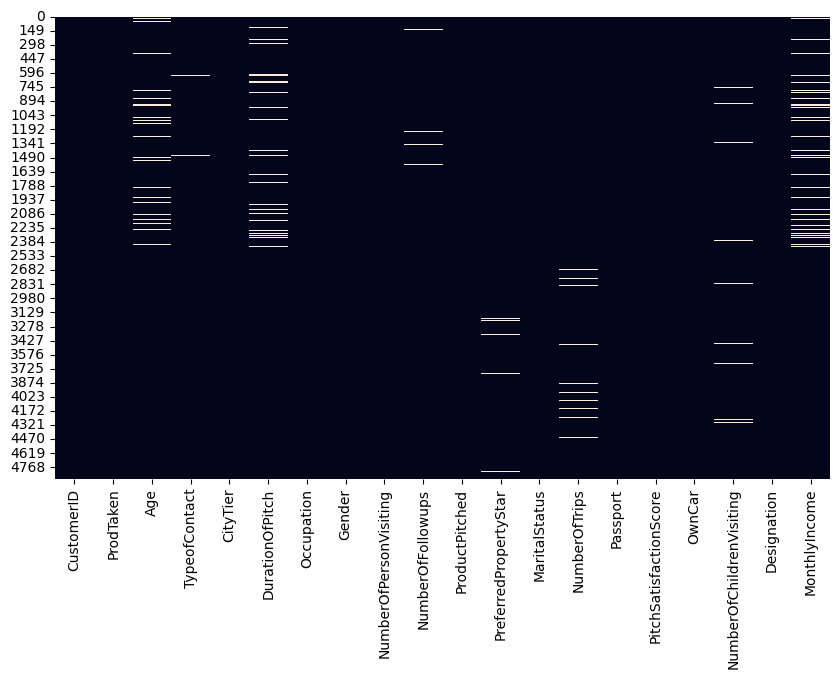

In [41]:
#plotting the missing values
fig=plt.figure(figsize=(10,6))
sns.heatmap(travel_df.isnull(),cbar=False)

In [42]:
for col in travel_df[['Gender','MaritalStatus','TypeofContact']].columns:
    print(f"Column: {col}")
    print(travel_df[col].value_counts())
    print("-"*40)

Column: Gender
Gender
Male       2916
Female     1817
Fe Male     155
Name: count, dtype: int64
----------------------------------------
Column: MaritalStatus
MaritalStatus
Married      2340
Divorced      950
Single        916
Unmarried     682
Name: count, dtype: int64
----------------------------------------
Column: TypeofContact
TypeofContact
Self Enquiry       3444
Company Invited    1419
Name: count, dtype: int64
----------------------------------------


In [43]:
travel_df['Gender'] = travel_df['Gender'].replace('Fe Male', 'Female')
travel_df['MaritalStatus'] = travel_df['MaritalStatus'].replace('Single', 'Unmarried')


In [44]:
##checking missing percentage
feature_with_na=[feature for feature in travel_df.columns if travel_df[feature].isnull().sum()>=1]
for feature in feature_with_na:
    print(feature,np.round(travel_df[feature].isnull().mean()*100,5), '% missing values')

Age 4.62357 % missing values
TypeofContact 0.51146 % missing values
DurationOfPitch 5.13502 % missing values
NumberOfFollowups 0.92062 % missing values
PreferredPropertyStar 0.53191 % missing values
NumberOfTrips 2.86416 % missing values
NumberOfChildrenVisiting 1.35025 % missing values
MonthlyIncome 4.76678 % missing values


In [45]:
# statistics on numerical columns (Null cols)
travel_df[feature_with_na].select_dtypes(exclude='object').describe().T

,count,mean,std,min,25%,50%,75%,max
Age,4662.0,37.622265,9.316387,18.0,31.0,36.0,44.0,61.0
DurationOfPitch,4637.0,15.490835,8.519643,5.0,9.0,13.0,20.0,127.0
NumberOfFollowups,4843.0,3.708445,1.002509,1.0,3.0,4.0,4.0,6.0
PreferredPropertyStar,4862.0,3.581037,0.798009,3.0,3.0,3.0,4.0,5.0
NumberOfTrips,4748.0,3.236521,1.849019,1.0,2.0,3.0,4.0,22.0
NumberOfChildrenVisiting,4822.0,1.187267,0.857861,0.0,1.0,1.0,2.0,3.0
MonthlyIncome,4655.0,23619.853491,5380.698361,1000.0,20346.0,22347.0,25571.0,98678.0


In [46]:
#Handling the missing values
travel_df['Age']=travel_df['Age'].fillna(travel_df['Age'].median(),inplace=True)
travel_df['NumberOfFollowups']=travel_df['NumberOfFollowups'].fillna(travel_df['NumberOfFollowups'].mode()[0],inplace=True)
travel_df['DurationOfPitch']=travel_df['DurationOfPitch'].fillna(travel_df['DurationOfPitch'].median(),inplace=True)
travel_df['NumberOfChildrenVisiting']=travel_df['NumberOfChildrenVisiting'].fillna(travel_df['NumberOfChildrenVisiting'].mode()[0],inplace=True)
travel_df['PreferredPropertyStar']=travel_df['PreferredPropertyStar'].fillna(travel_df['PreferredPropertyStar'].mode()[0],inplace=True)
travel_df['MonthlyIncome']=travel_df['MonthlyIncome'].fillna(travel_df['MonthlyIncome'].median(),inplace=True)
travel_df['NumberOfTrips']=travel_df['NumberOfTrips'].fillna(travel_df['NumberOfTrips'].median(),inplace=True)
travel_df['TypeofContact']=travel_df['TypeofContact'].fillna(travel_df['TypeofContact'].mode()[0],inplace=True)


In [47]:
travel_df.head(2)

,CustomerID,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome
0,200000,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3,3.0,Deluxe,3.0,Unmarried,1.0,1,2,1,0.0,Manager,20993.0
1,200001,0,49.0,Company Invited,1,14.0,Salaried,Male,3,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,2.0,Manager,20130.0


In [48]:
travel_df.drop('CustomerID',axis=1,inplace=True)

In [49]:
travel_df['NumberofPeopleVisiting']=travel_df['NumberOfPersonVisiting']+travel_df['NumberOfChildrenVisiting']
travel_df.drop(columns=['NumberOfChildrenVisiting','NumberOfPersonVisiting'], inplace=True)

In [50]:
travel_df.sample(5)

,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,Designation,MonthlyIncome,NumberofPeopleVisiting
1259,0,30.0,Self Enquiry,1,22.0,Salaried,Male,1.0,Deluxe,3.0,Married,4.0,0,1,1,Manager,20294.0,2.0
4473,0,39.0,Self Enquiry,1,9.0,Small Business,Male,4.0,Basic,3.0,Married,8.0,1,4,0,Executive,21735.0,7.0
2714,0,56.0,Self Enquiry,1,7.0,Small Business,Male,4.0,King,5.0,Unmarried,3.0,1,2,1,VP,37723.0,4.0
1038,0,48.0,Self Enquiry,3,13.0,Small Business,Male,3.0,Deluxe,5.0,Married,5.0,0,4,1,Manager,20486.0,4.0
4608,0,34.0,Self Enquiry,1,7.0,Salaried,Female,5.0,Deluxe,3.0,Unmarried,2.0,0,4,1,Manager,25627.0,5.0


Text(0.5, 1.0, 'Count of people by occupation')

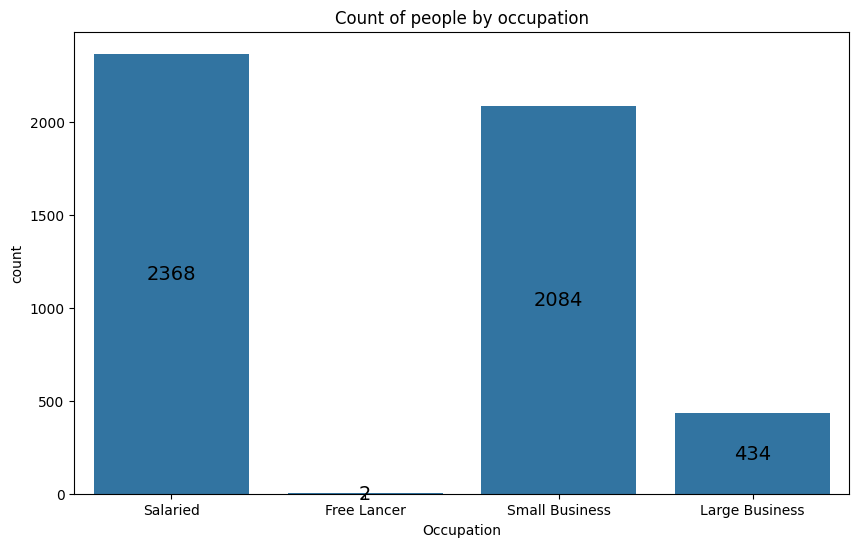

In [51]:
fig,ax=plt.subplots(figsize=(10,6))
sns.countplot(data=travel_df,x='Occupation',ax=ax)
for container in ax.containers:
    ax.bar_label(container,color='black',size=14,label_type='center')
    
plt.title('Count of people by occupation')

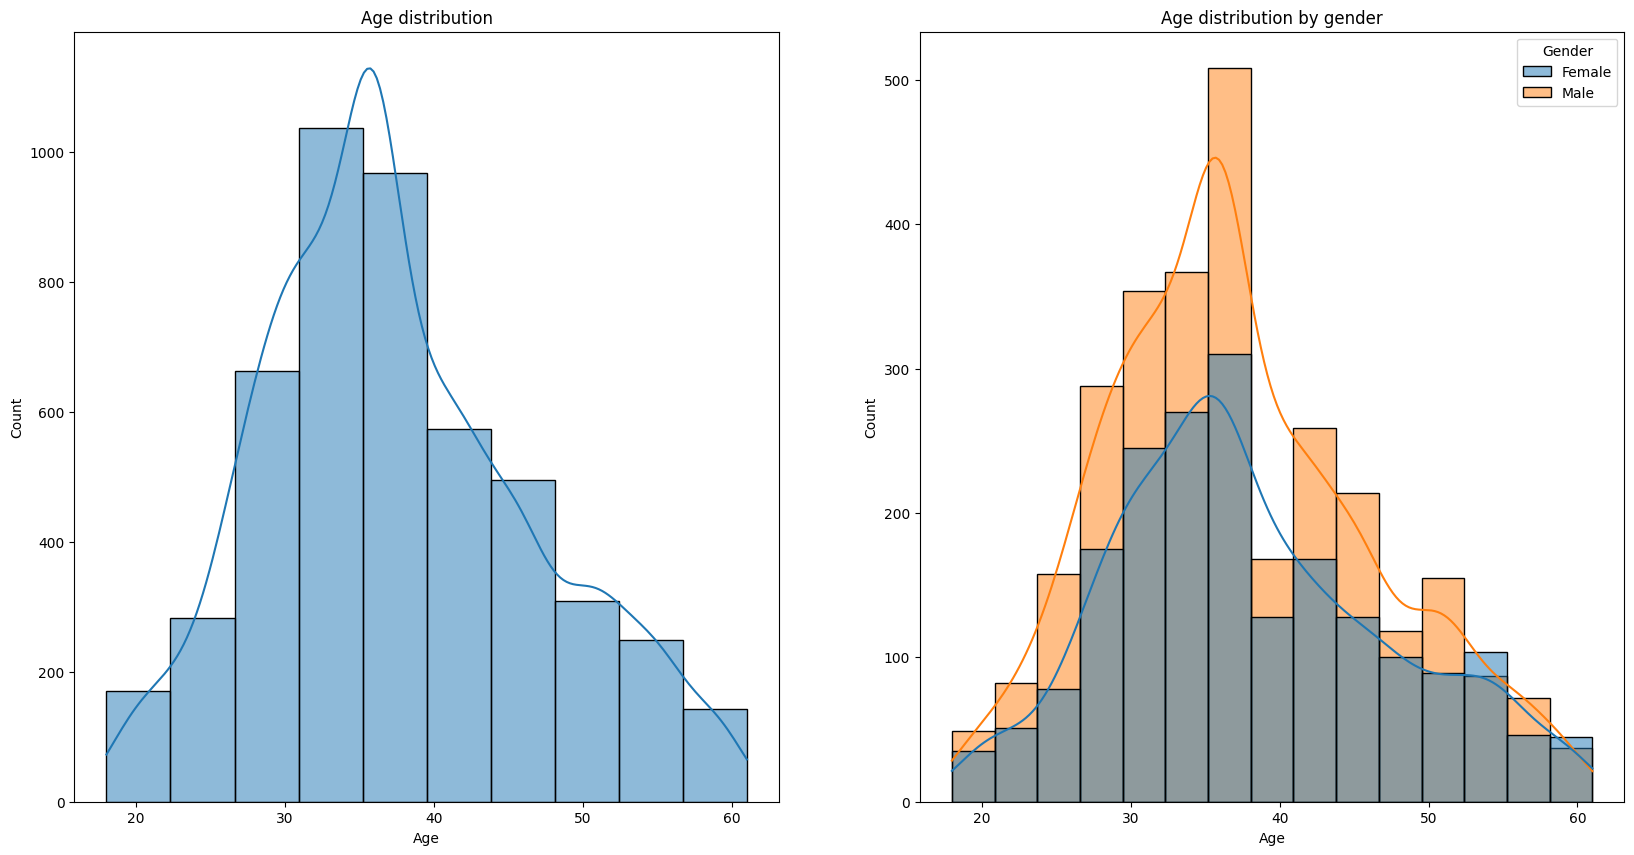

In [52]:
f,ax=plt.subplots(1,2,figsize=(20,10))
plt.subplot(121)
sns.histplot(data=travel_df,x='Age',bins=10,kde=True)
plt.title("Age distribution")
plt.subplot(122)
sns.histplot(data=travel_df,x='Age',hue='Gender',kde=True,bins=15,alpha=0.5)
plt.title("Age distribution by gender")
plt.show()



Text(0.5, 1.0, 'Gender Distribution')

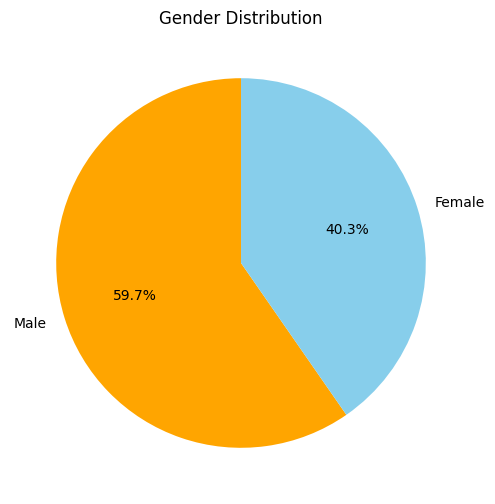

In [53]:
gender_count=travel_df['Gender'].value_counts()
plt.rcParams['figure.figsize'] = (8, 6)
plt.pie(gender_count,labels=gender_count.index,autopct='%1.1f%%',
        colors=['orange','skyblue'],
        startangle=90)
plt.axis('off')
plt.title('Gender Distribution')

Text(0.5, 1.0, 'Designation Distribution')

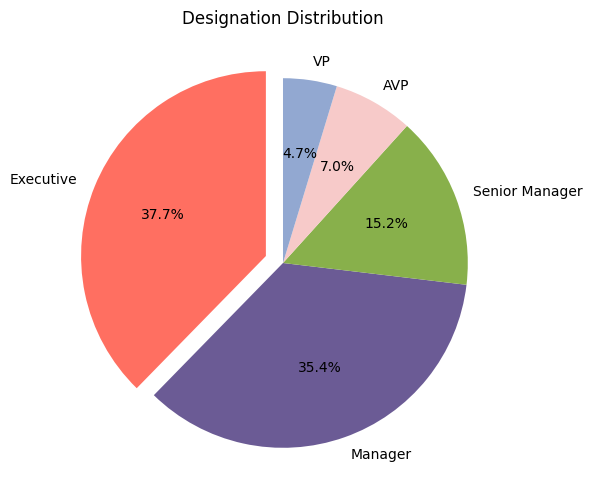

In [54]:
Designation_count=travel_df['Designation'].value_counts()
plt.rcParams['figure.figsize'] = (8, 6)
plt.pie(Designation_count,labels=Designation_count.index,autopct='%1.1f%%',
        colors=['#FF6F61', '#6B5B95', '#88B04B', '#F7CAC9', '#92A8D1'],
        startangle=90,
        explode=[0.1,0.0,0.0,0.0,0.0])
plt.axis('off')
plt.title('Designation Distribution')

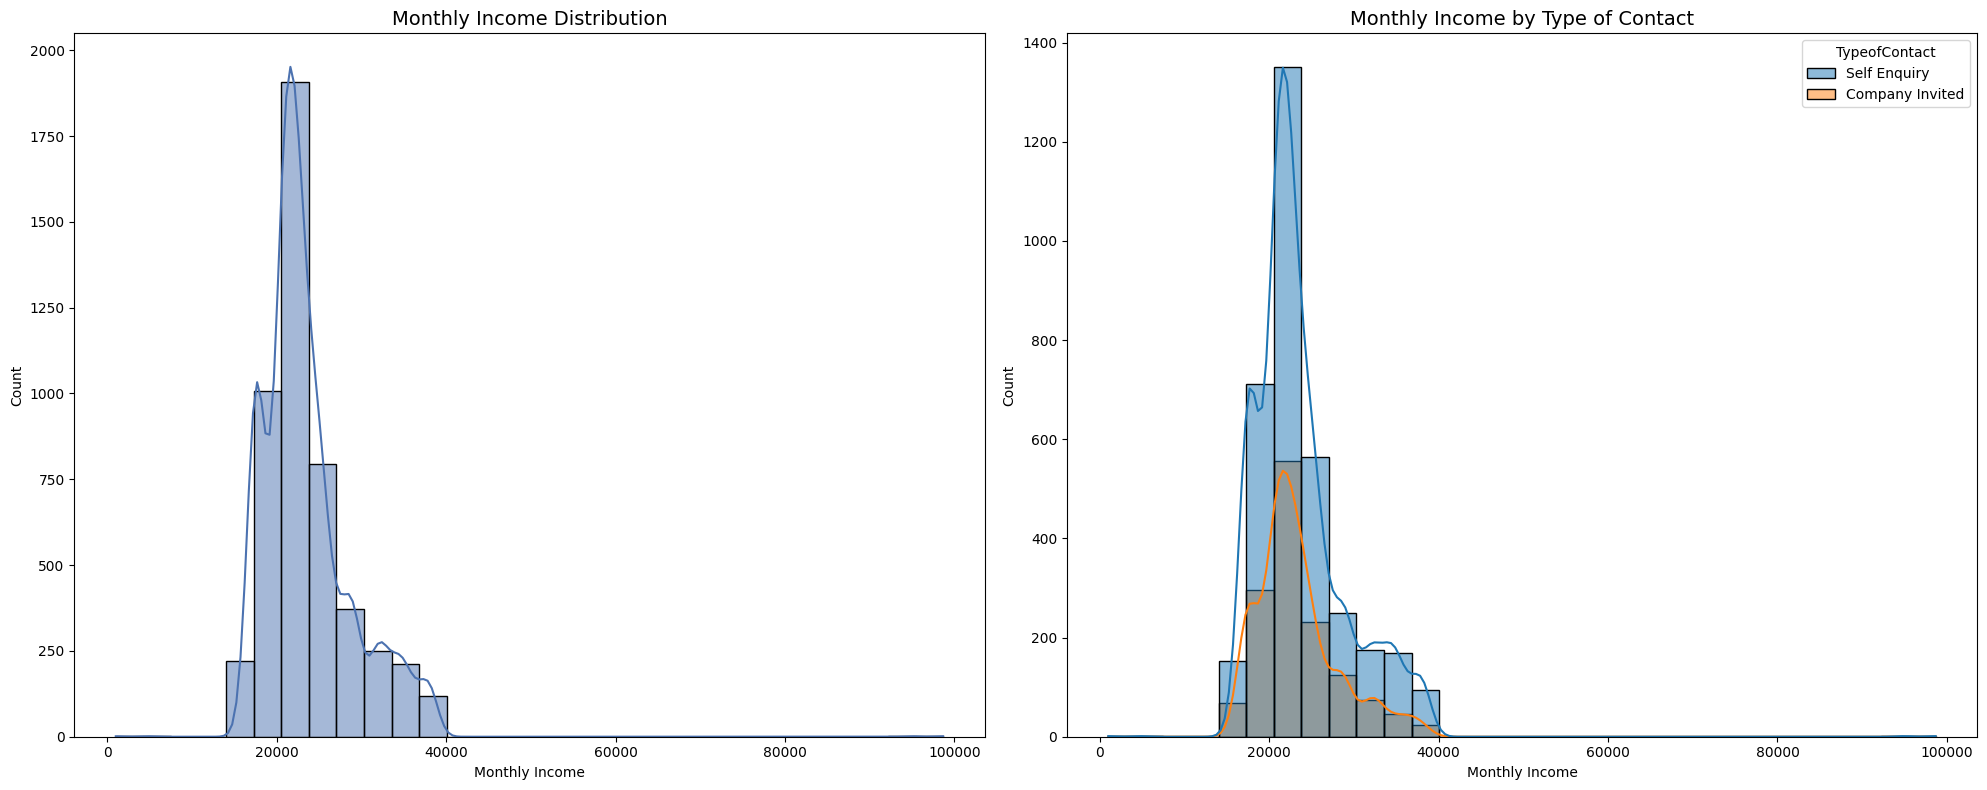

In [55]:
f, ax = plt.subplots(1, 2, figsize=(20, 8))

# 🔹 Plot 1: Overall Income Distribution
sns.histplot(
    data=travel_df,
    x='MonthlyIncome',
    bins=30,
    kde=True,
    ax=ax[0],
    color='#4C72B0'
)
ax[0].set_title("Monthly Income Distribution", fontsize=14)
ax[0].set_xlabel("Monthly Income")
ax[0].set_ylabel("Count")


# 🔹 Plot 2: Income by Type of Contact
sns.histplot(
    data=travel_df,
    x='MonthlyIncome',
    hue='TypeofContact',
    bins=30,
    kde=True,
    alpha=0.5,
    ax=ax[1]
)
ax[1].set_title("Monthly Income by Type of Contact", fontsize=14)
ax[1].set_xlabel("Monthly Income")
ax[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Identifying outlier in monthly income')

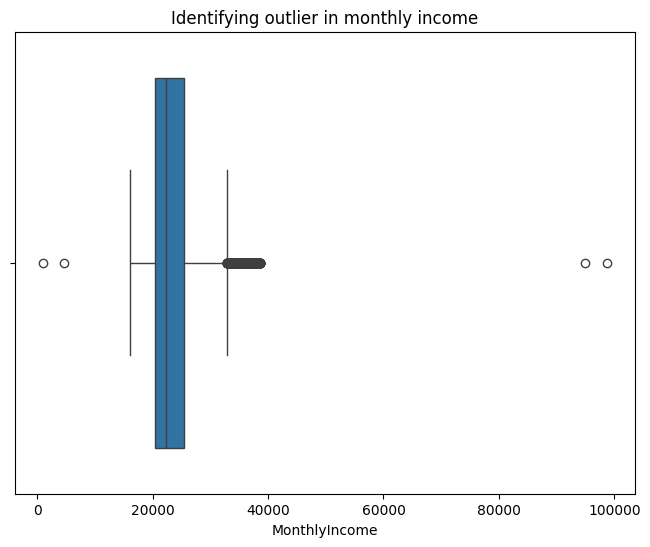

In [56]:
sns.boxplot(data=travel_df, x='MonthlyIncome')
plt.title('Identifying outlier in monthly income')


## Insight

There are few people who are earning extremly high and some of the people are earning extremly low than most of the people 

<Axes: xlabel='ProductPitched', ylabel='count'>

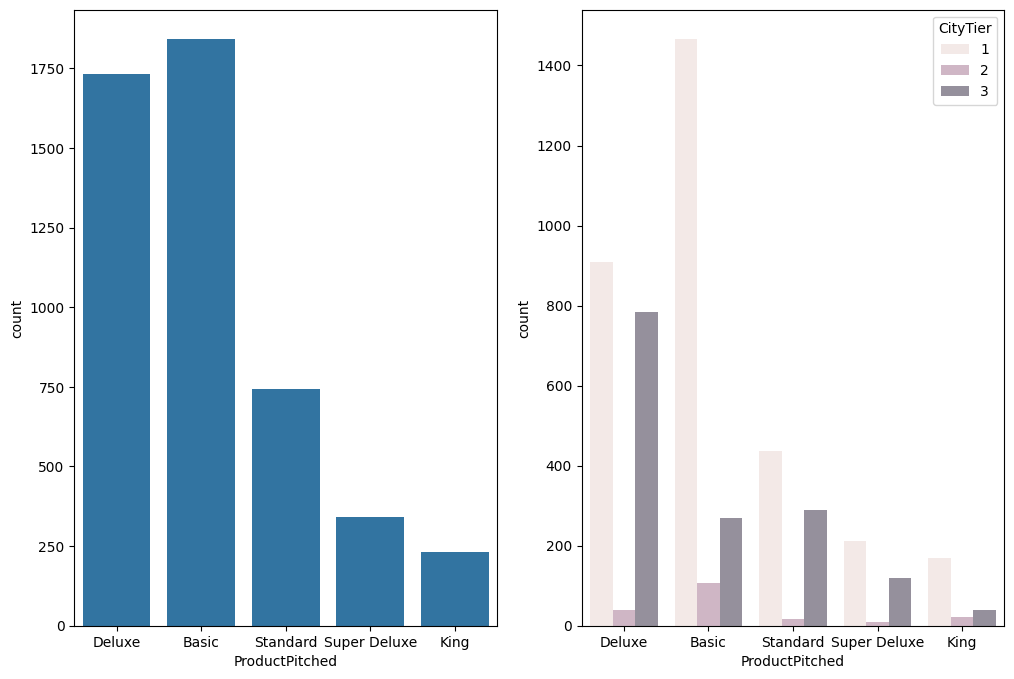

In [57]:
fig=plt.subplots(1,2,figsize=(12,8))
plt.subplot(121)
sns.countplot(data=travel_df,x='ProductPitched')
plt.subplot(122)
sns.countplot(data=travel_df,x='ProductPitched',hue='CityTier',alpha=0.5)

In [58]:
travel_df.head()

,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,Designation,MonthlyIncome,NumberofPeopleVisiting
0,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3.0,Deluxe,3.0,Unmarried,1.0,1,2,1,Manager,20993.0,3.0
1,0,49.0,Company Invited,1,14.0,Salaried,Male,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,Manager,20130.0,5.0
2,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,4.0,Basic,3.0,Unmarried,7.0,1,3,0,Executive,17090.0,3.0
3,0,33.0,Company Invited,1,9.0,Salaried,Female,3.0,Basic,3.0,Divorced,2.0,1,5,1,Executive,17909.0,3.0
4,0,36.0,Self Enquiry,1,8.0,Small Business,Male,3.0,Basic,4.0,Divorced,1.0,0,5,1,Executive,18468.0,2.0


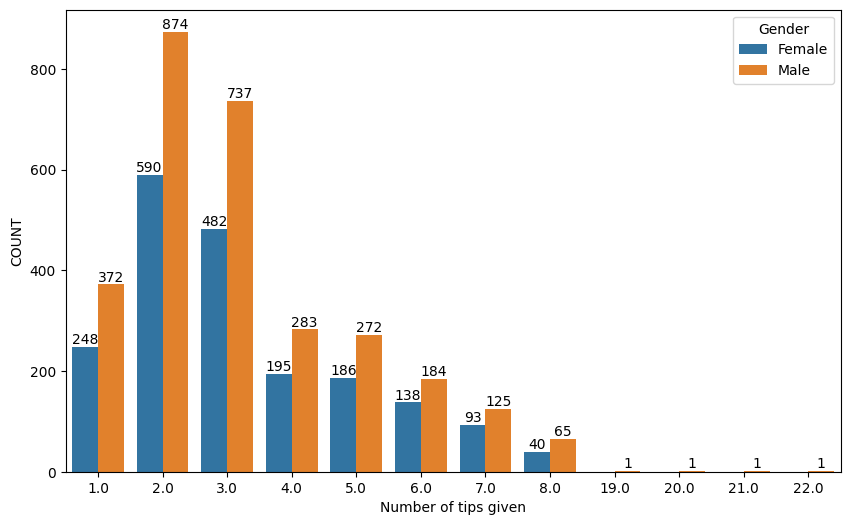

In [59]:
fig,ax=plt.subplots(figsize=(10,6))
sns.countplot(data=travel_df,x='NumberOfTrips',hue='Gender',ax=ax)
plt.xlabel('Number of tips given')
plt.ylabel('COUNT')

for container in ax.containers:
    ax.bar_label(container,color='black',size=10,label_type='edge')


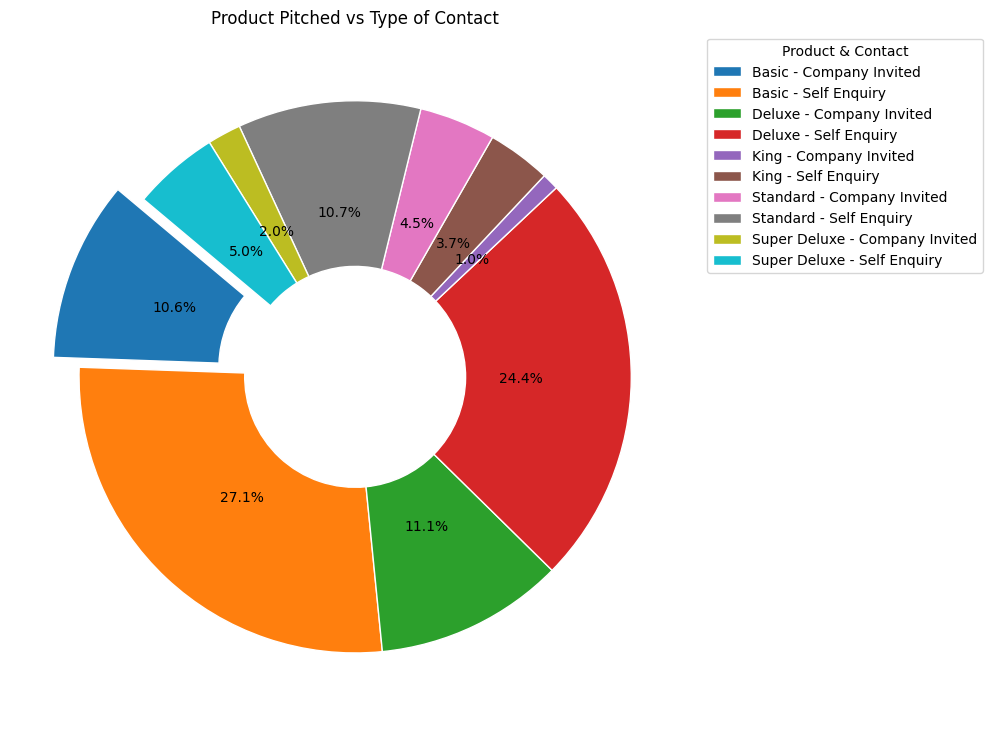

In [60]:
import matplotlib.pyplot as plt

grouped = travel_df.groupby(['ProductPitched', 'TypeofContact']).size().reset_index(name='Count')
grouped['Label'] = grouped['ProductPitched'] + " - " + grouped['TypeofContact']

plt.figure(figsize=(10,10))

plt.pie(
    grouped['Count'],
    labels=None,   # ❗ remove labels from chart
    autopct='%1.1f%%',
    startangle=140,
    wedgeprops={'width':0.6, 'edgecolor':'white'},
    explode = [0.1] + [0]*(len(grouped)-1)
)

plt.legend(
    grouped['Label'],
    title="Product & Contact",
    bbox_to_anchor=(1, 1),
)

plt.title("Product Pitched vs Type of Contact")
plt.tight_layout()
plt.show()

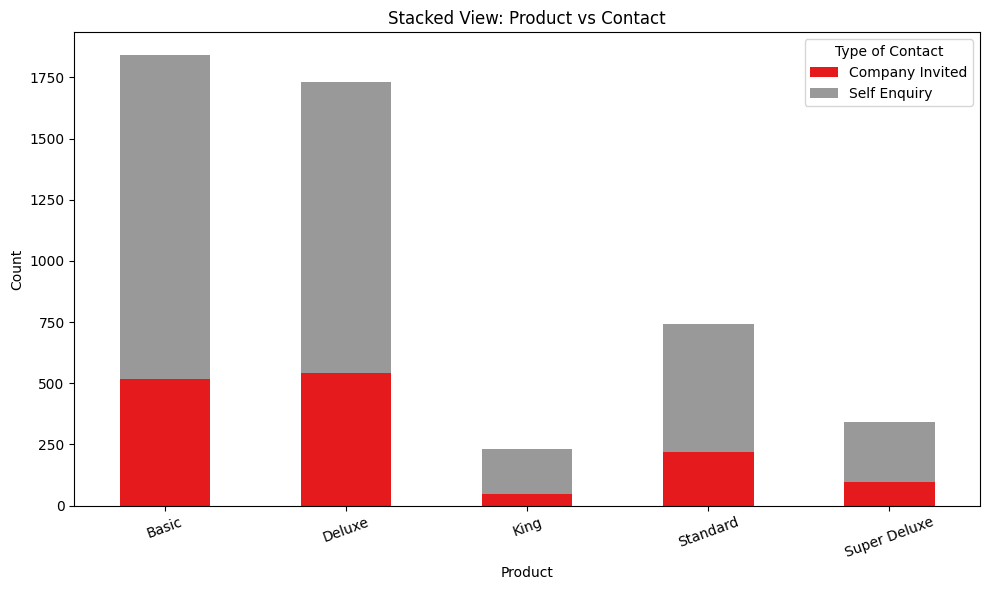

In [61]:
pd.crosstab(
    travel_df['ProductPitched'],
    travel_df['TypeofContact']
).plot(kind='bar', stacked=True, figsize=(10,6), colormap='Set1')

plt.title("Stacked View: Product vs Contact")
plt.xlabel("Product")
plt.ylabel("Count")

plt.xticks(rotation=20)
plt.legend(title='Type of Contact')

plt.tight_layout()
plt.show()

In [62]:
travel_df.sample(5)

,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,Designation,MonthlyIncome,NumberofPeopleVisiting
1898,0,47.0,Self Enquiry,1,8.0,Small Business,Female,3.0,Deluxe,3.0,Married,6.0,0,1,0,Manager,20070.0,3.0
25,0,53.0,Self Enquiry,1,11.0,Salaried,Female,3.0,King,3.0,Married,5.0,0,5,0,VP,34094.0,3.0
3976,0,51.0,Self Enquiry,1,14.0,Small Business,Female,5.0,King,3.0,Married,3.0,1,4,1,VP,37418.0,5.0
699,0,52.0,Self Enquiry,1,6.0,Salaried,Male,3.0,Super Deluxe,3.0,Divorced,3.0,0,2,1,AVP,32099.0,4.0
4441,0,33.0,Self Enquiry,3,17.0,Small Business,Male,4.0,Deluxe,3.0,Unmarried,3.0,0,4,1,Manager,24074.0,5.0


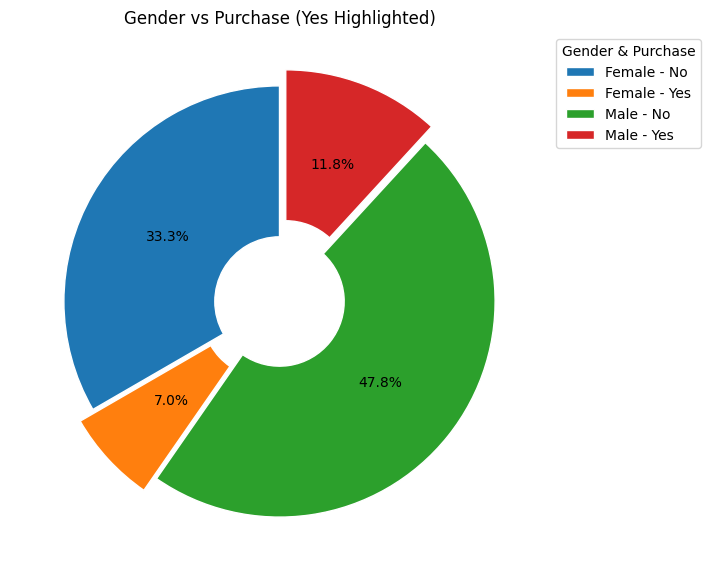

In [63]:
grouped = travel_df.groupby(['Gender','ProdTaken']).size().reset_index(name='Count')

grouped['Label'] = grouped['Gender'] + " - " + grouped['ProdTaken'].map({0:'No',1:'Yes'})

# 🔹 explode only "Yes" parts
explode = [0.08 if 'Yes' in label else 0 for label in grouped['Label']]

plt.figure(figsize=(7,7))

plt.pie(
    grouped['Count'],
    labels=None,   # remove outside clutter
    autopct='%1.1f%%',  # show inside
    startangle=90,
    explode=explode,
    wedgeprops={'width':0.7, 'edgecolor':'white'}
)

plt.legend(
    grouped['Label'],
    title="Gender & Purchase",
    bbox_to_anchor=(1, 1)
)

plt.title("Gender vs Purchase (Yes Highlighted)")
plt.show()

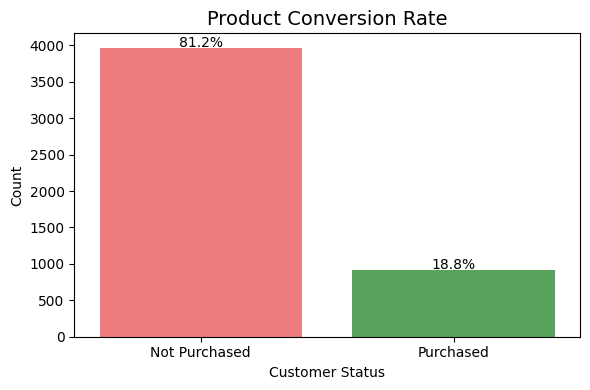

In [64]:


# Count values
counts = travel_df['ProdTaken'].value_counts()

# Map labels
labels = counts.index.map({0: 'Not Purchased', 1: 'Purchased'})

plt.figure(figsize=(6,4))

sns.barplot(
    x=labels,
    y=counts.values,
    palette=['#FF6B6B', '#4CAF50']
)

plt.title("Product Conversion Rate", fontsize=14)
plt.xlabel("Customer Status")
plt.ylabel("Count")

# 🔹 Add percentage labels
total = counts.sum()
for i, v in enumerate(counts.values):
    plt.text(i, v + 5, f"{(v/total)*100:.1f}%", ha='center')

plt.tight_layout()
plt.show()

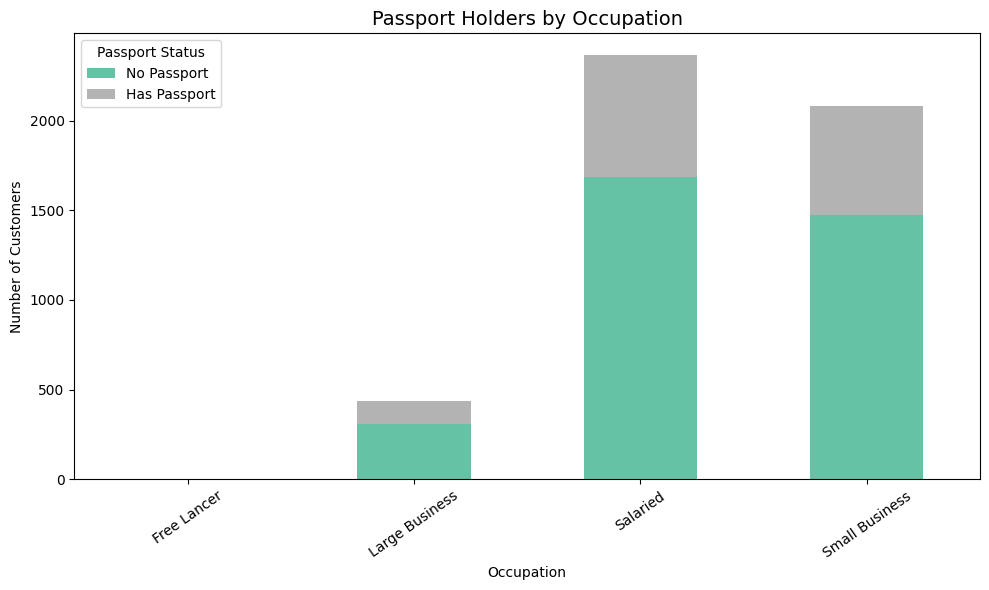

In [65]:
import matplotlib.pyplot as plt
import pandas as pd

# Create crosstab
data = pd.crosstab(
    travel_df['Occupation'],
    travel_df['Passport']
)

# Rename columns for clarity
data.columns = ['No Passport', 'Has Passport']

# Plot
data.plot(
    kind='bar',
    stacked=True,
    figsize=(10,6),
    colormap='Set2'
)

plt.title("Passport Holders by Occupation", fontsize=14)
plt.xlabel("Occupation")
plt.ylabel("Number of Customers")

plt.xticks(rotation=35)
plt.legend(title="Passport Status")

plt.tight_layout()
plt.show()

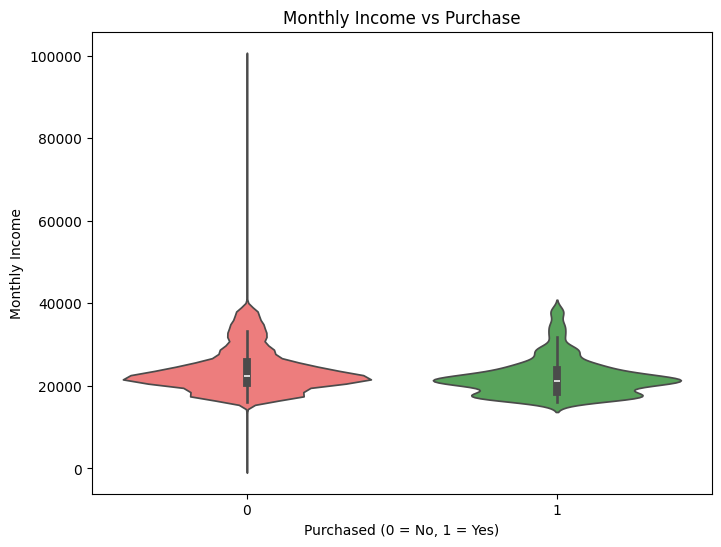

In [66]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.violinplot(
    data=travel_df,
    x='ProdTaken',
    y='MonthlyIncome',
    palette=['#FF6B6B', '#4CAF50']
)

plt.title("Monthly Income vs Purchase")
plt.xlabel("Purchased (0 = No, 1 = Yes)")
plt.ylabel("Monthly Income")

plt.show()

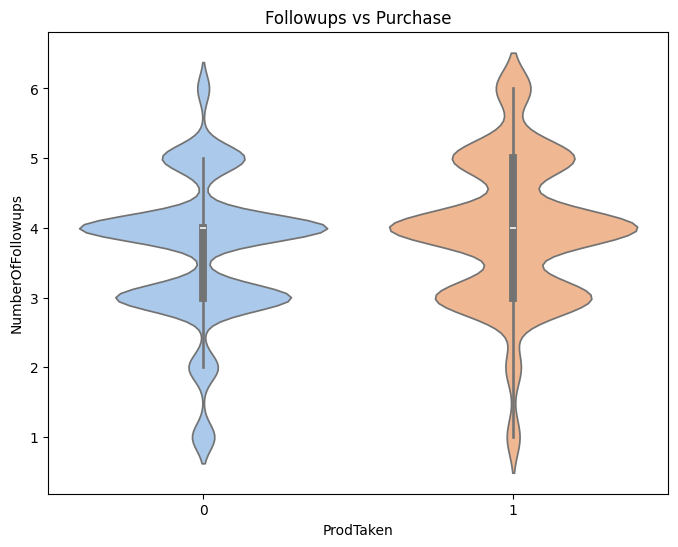

In [67]:
plt.figure(figsize=(8,6))

sns.violinplot(
    data=travel_df,
    x='ProdTaken',
    y='NumberOfFollowups',
    palette='pastel'
)

plt.title("Followups vs Purchase")
plt.show()

In [68]:
travel_df.head(2)

,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,Designation,MonthlyIncome,NumberofPeopleVisiting
0,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3.0,Deluxe,3.0,Unmarried,1.0,1,2,1,Manager,20993.0,3.0
1,0,49.0,Company Invited,1,14.0,Salaried,Male,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,Manager,20130.0,5.0


In [69]:
travel_df['DurationOfPitch'].unique()

array([  6.,  14.,   8.,   9.,  30.,  29.,  33.,  22.,  21.,  32.,  25.,
        27.,  11.,  17.,  15.,  13.,  12.,  16.,  10.,  31.,  18.,  24.,
        35.,  28.,  20.,  26.,  34.,  23.,   5.,  19., 126.,   7.,  36.,
       127.])